### Clustering All features

🎯 Adjusted Rand Index (ARI): 0.1132
📏 Silhouette Score         : 0.1958


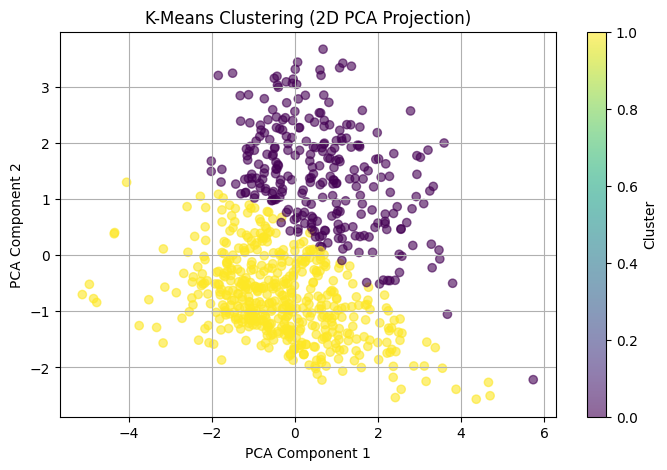

In [8]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, RobustScaler, minmax_scale
from sklearn.metrics import adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Load data dan pisahkan fitur
df = pd.read_csv('../Data Analytics/Git_Clone_PakHandaru/datasets/pima_indians_diabetes.csv')

df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

X = df.drop(columns='Outcome').values
y_true = df['Outcome'].values  # disimpan hanya untuk evaluasi (bukan training)

# 2. Normalisasi (standard scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Clustering dengan KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 4. Evaluasi (pakai label asli hanya untuk metrik)
ari = adjusted_rand_score(y_true, cluster_labels)
sil_score = silhouette_score(X_scaled, cluster_labels)

print(f"🎯 Adjusted Rand Index (ARI): {ari:.4f}") # ARI mengukur seberapa mirip hasil clustering dengan label sebenarnya (Outcome).
print(f"📏 Silhouette Score         : {sil_score:.4f}") # Seberapa baik objek cocok dengan clusternya sendiri dan berbeda dengan cluster lain.

# 5. Visualisasi 2D dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title("K-Means Clustering (2D PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


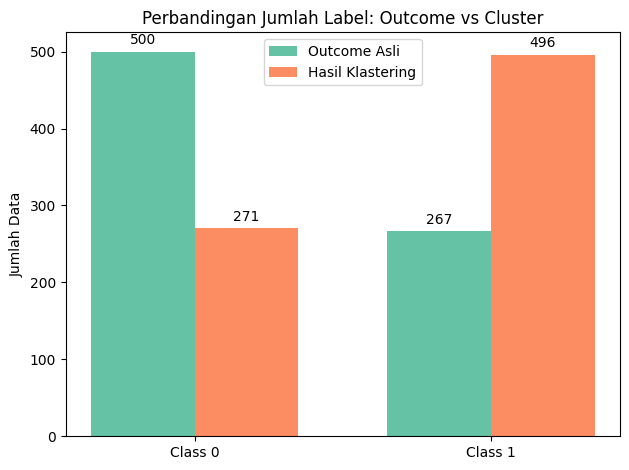

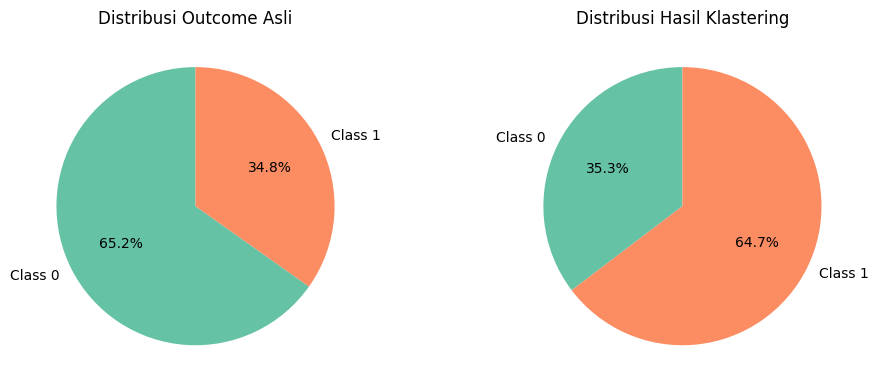

In [2]:
# Buat dataframe gabungan
df_compare = pd.DataFrame({
    'Outcome': y_true,
    'Cluster': cluster_labels
})

# Hitung jumlah masing-masing label
outcome_counts = df_compare['Outcome'].value_counts().sort_index()
cluster_counts = df_compare['Cluster'].value_counts().sort_index()

# Buat side-by-side bar chart
labels = ['Class 0', 'Class 1']
x = np.arange(len(labels))  # posisi label

width = 0.35  # lebar bar

fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, outcome_counts, width, label='Outcome Asli', color='#66c2a5')
bar2 = ax.bar(x + width/2, cluster_counts, width, label='Hasil Klastering', color='#fc8d62')

# Tambahkan label
ax.set_ylabel('Jumlah Data')
ax.set_title('Perbandingan Jumlah Label: Outcome vs Cluster')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Tampilkan nilai di atas bar
for bar in bar1 + bar2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart untuk Outcome
axes[0].pie(outcome_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[0].set_title('Distribusi Outcome Asli')

# Pie chart untuk Cluster
axes[1].pie(cluster_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Distribusi Hasil Klastering')

plt.tight_layout()
plt.show()

##### Terlihat bahwa data kelas 0 clustering sama dengan data kelas 1 di data asli

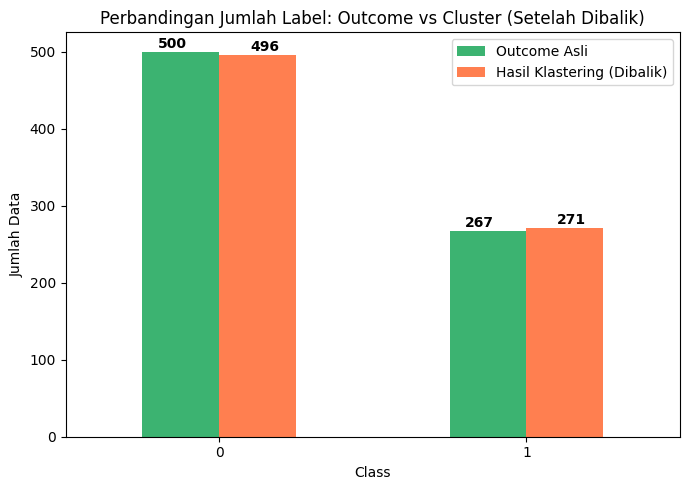

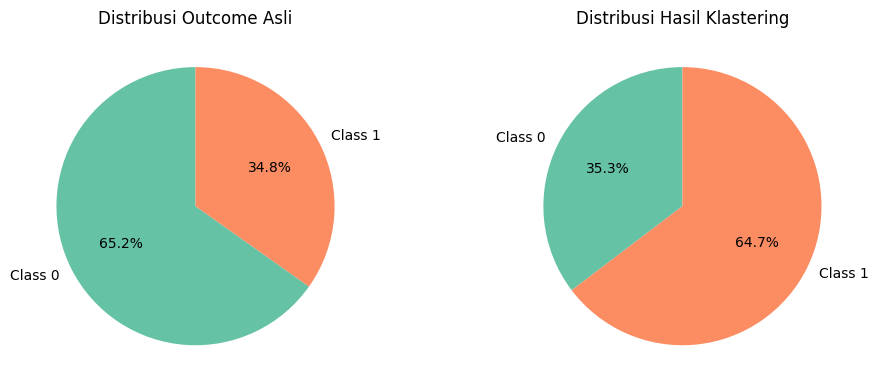

In [3]:
# 1. Buat DataFrame gabungan (kalau belum)
df_compare = pd.DataFrame({
    'Outcome': y_true,           # label asli
    'Cluster': cluster_labels    # hasil clustering
})

# Balik label cluster: 0 jadi 1, 1 jadi 0
df_compare['Cluster_Reversed'] = 1 - df_compare['Cluster']  # Cluster adalah hasil k-means

# Visualisasi perbandingan ulang
import matplotlib.pyplot as plt

counts = pd.DataFrame({
    'Outcome Asli': df_compare['Outcome'].value_counts().sort_index(),
    'Hasil Klastering (Dibalik)': df_compare['Cluster_Reversed'].value_counts().sort_index()
})

counts.plot(kind='bar', figsize=(7, 5), color=['mediumseagreen', 'coral'])
plt.title('Perbandingan Jumlah Label: Outcome vs Cluster (Setelah Dibalik)')
plt.xlabel('Class')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
for i, (v1, v2) in enumerate(zip(counts['Outcome Asli'], counts['Hasil Klastering (Dibalik)'])):
    plt.text(i - 0.2, v1 + 5, str(v1), fontweight='bold')
    plt.text(i + 0.1, v2 + 5, str(v2), fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart untuk Outcome
axes[0].pie(outcome_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[0].set_title('Distribusi Outcome Asli')

# Pie chart untuk Cluster
axes[1].pie(cluster_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Distribusi Hasil Klastering')

plt.tight_layout()
plt.show()

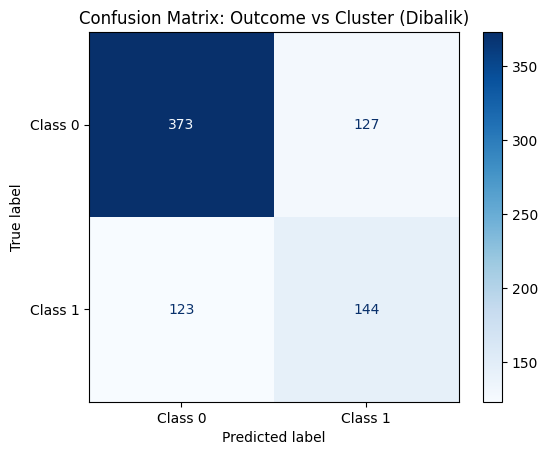

📊 Classification Report (Outcome vs Cluster - Dibalik)
✅ Accuracy : 0.6741
🎯 Precision: 0.5314
📈 Recall   : 0.5393
💡 F1 Score : 0.5353


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Balik label cluster (0 ⇄ 1) jika belum
cluster_reversed = 1 - cluster_labels

# Hitung confusion matrix
cm = confusion_matrix(y_true, cluster_reversed)

# Tampilkan visualisasi confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Outcome vs Cluster (Dibalik)")
plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluasi metrik klasifikasi
accuracy = accuracy_score(y_true, cluster_reversed)
precision = precision_score(y_true, cluster_reversed)
recall = recall_score(y_true, cluster_reversed)
f1 = f1_score(y_true, cluster_reversed)

print("📊 Classification Report (Outcome vs Cluster - Dibalik)")
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision: {precision:.4f}")
print(f"📈 Recall   : {recall:.4f}")
print(f"💡 F1 Score : {f1:.4f}")


🎯 Adjusted Rand Index (ARI): 0.1132


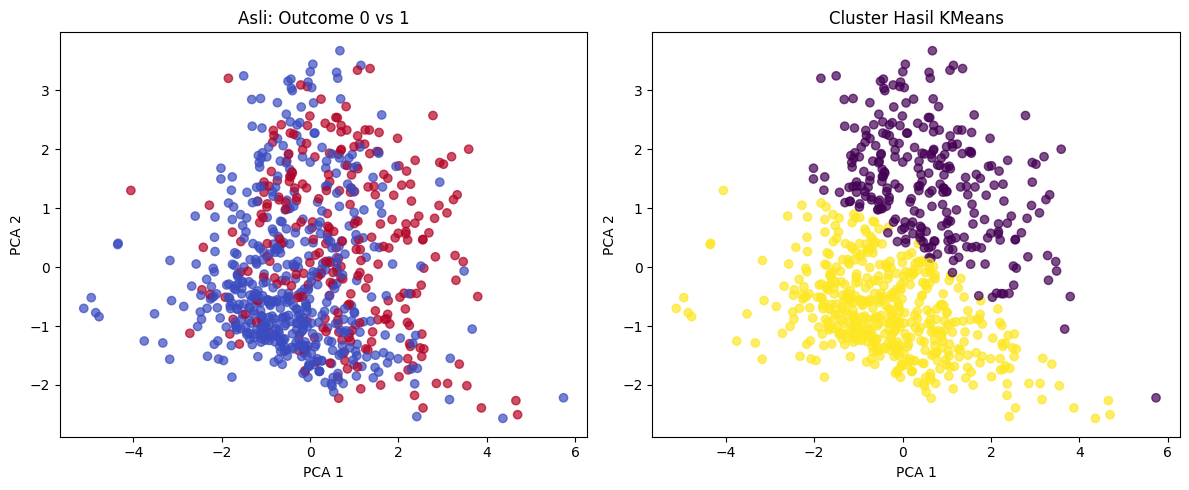

In [59]:
# 2. Adjusted Rand Index sudah kita hitung tadi
print(f"🎯 Adjusted Rand Index (ARI): {ari:.4f}")

# 3. Visualisasi label asli vs cluster
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# PCA hasil
ax[0].scatter(X_pca[:,0], X_pca[:,1], c=y_true, cmap='coolwarm', alpha=0.7)
ax[0].set_title("Asli: Outcome 0 vs 1")
ax[0].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2")

ax[1].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[1].set_title("Cluster Hasil KMeans")
ax[1].set_xlabel("PCA 1")
ax[1].set_ylabel("PCA 2")

plt.tight_layout()
plt.show()


### Feature Selection dengan T-Test

In [60]:
from scipy.stats import ttest_ind

# Loop semua kolom numerik vs Outcome
for col in df.columns[:-1]:  # loop kecuali kolom 'Outcome'
    group0 = df[df['Outcome'] == 0][col]
    group1 = df[df['Outcome'] == 1][col]

    stat, p = ttest_ind(group0, group1, equal_var=False)  # Gunakan Welch’s t-test
    print(f"{col:<25} → p-value = {p:.4f}")

Pregnancies               → p-value = 0.0000
Glucose                   → p-value = 0.0000
BloodPressure             → p-value = 0.0887
SkinThickness             → p-value = 0.0544
Insulin                   → p-value = 0.0009
BMI                       → p-value = 0.0000
DiabetesPedigreeFunction  → p-value = 0.0000
Age                       → p-value = 0.0000


### Clustering 6 features

🎯 Adjusted Rand Index (ARI): 0.1171
📏 Silhouette Score         : 0.2426


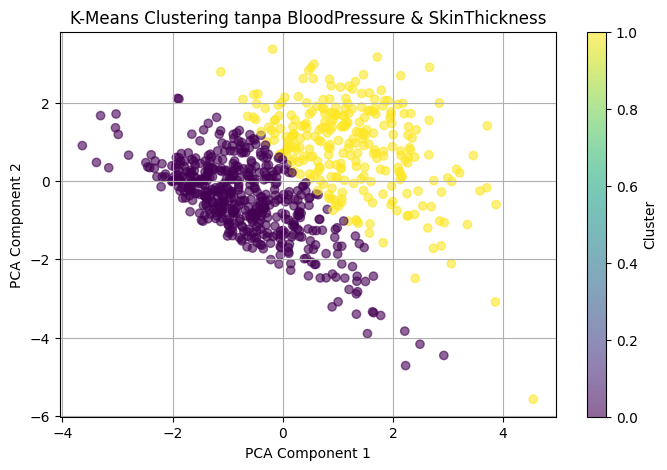

In [ ]:
# 2. Hapus kolom BloodPressure dan SkinThickness dari fitur
X = df.drop(columns=['Outcome', 'BloodPressure', 'SkinThickness']).values
y_true = df['Outcome'].values  # Simpan label asli untuk evaluasi

# 3. Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Clustering KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 5. Evaluasi clustering
ari = adjusted_rand_score(y_true, cluster_labels)
sil_score = silhouette_score(X_scaled, cluster_labels)

print(f"🎯 Adjusted Rand Index (ARI): {ari:.4f}")
print(f"📏 Silhouette Score         : {sil_score:.4f}")

# 6. Visualisasi 2D (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title("K-Means Clustering tanpa BloodPressure & SkinThickness")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

🎯 Adjusted Rand Index (ARI): 0.1171


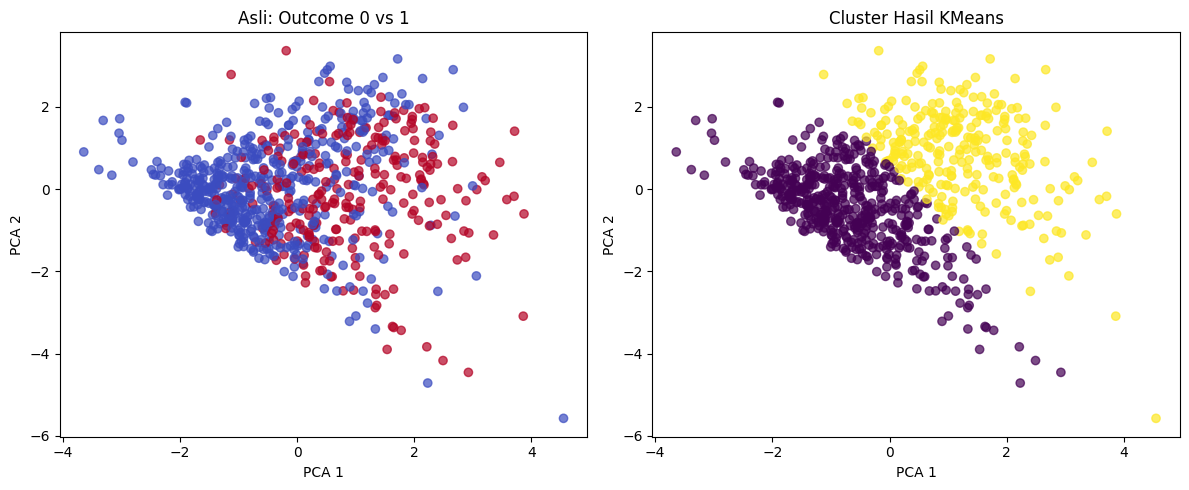

In [68]:
# 2. Adjusted Rand Index sudah kita hitung tadi
print(f"🎯 Adjusted Rand Index (ARI): {ari:.4f}")

# 3. Visualisasi label asli vs cluster
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# PCA hasil
ax[0].scatter(X_pca[:,0], X_pca[:,1], c=y_true, cmap='coolwarm', alpha=0.7)
ax[0].set_title("Asli: Outcome 0 vs 1")
ax[0].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2")

ax[1].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[1].set_title("Cluster Hasil KMeans")
ax[1].set_xlabel("PCA 1")
ax[1].set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

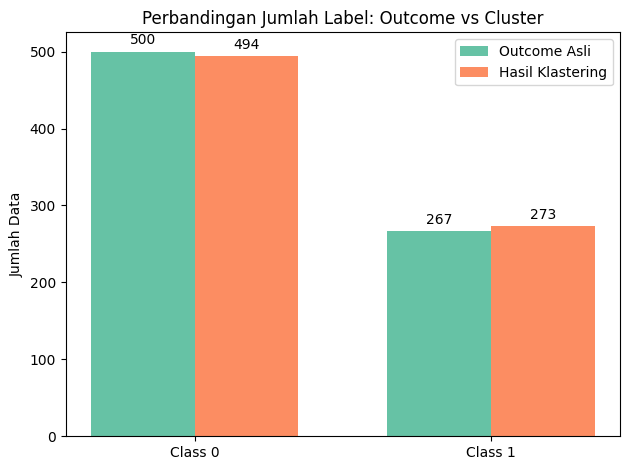

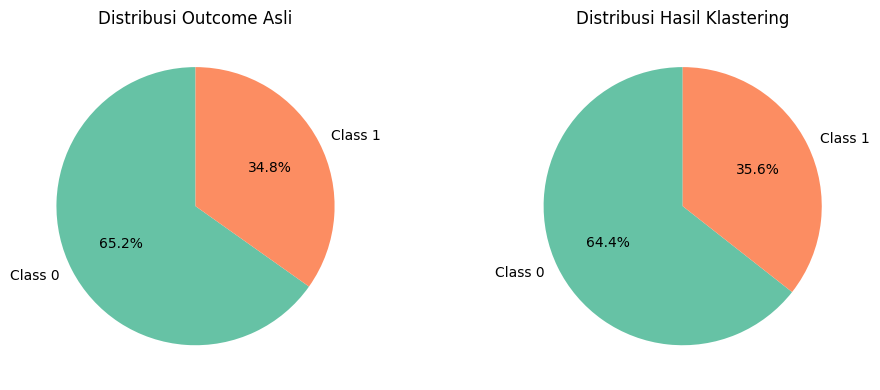

In [63]:
# Buat dataframe gabungan
df_compare2 = pd.DataFrame({
    'Outcome': y_true,
    'Cluster': cluster_labels
})

# Hitung jumlah masing-masing label
outcome_counts = df_compare2['Outcome'].value_counts().sort_index()
cluster_counts = df_compare2['Cluster'].value_counts().sort_index()

# Buat side-by-side bar chart
labels = ['Class 0', 'Class 1']
x = np.arange(len(labels))  # posisi label

width = 0.35  # lebar bar

fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, outcome_counts, width, label='Outcome Asli', color='#66c2a5')
bar2 = ax.bar(x + width/2, cluster_counts, width, label='Hasil Klastering', color='#fc8d62')

# Tambahkan label
ax.set_ylabel('Jumlah Data')
ax.set_title('Perbandingan Jumlah Label: Outcome vs Cluster')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Tampilkan nilai di atas bar
for bar in bar1 + bar2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart untuk Outcome
axes[0].pie(outcome_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[0].set_title('Distribusi Outcome Asli')

# Pie chart untuk Cluster
axes[1].pie(cluster_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Distribusi Hasil Klastering')

plt.tight_layout()
plt.show()


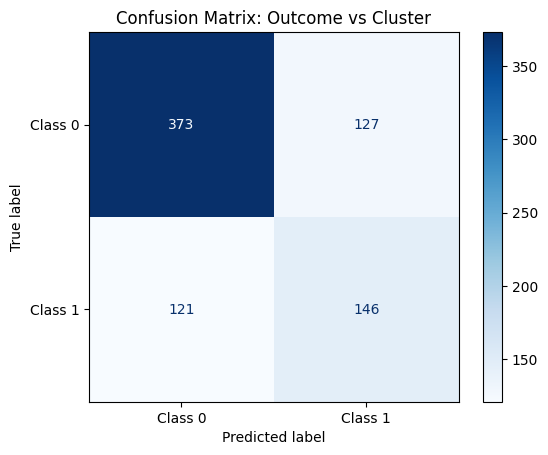

📊 Classification Report (Outcome vs Cluster)
✅ Accuracy : 0.6741
🎯 Precision: 0.5314
📈 Recall   : 0.5393
💡 F1 Score : 0.5353
🔵 ROC AUC  : 0.6427


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Hitung confusion matrix
cm = confusion_matrix(y_true, cluster_labels)

# Tampilkan visualisasi confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Outcome vs Cluster")
plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluasi metrik klasifikasi
accuracy = accuracy_score(y_true, cluster_reversed)
precision = precision_score(y_true, cluster_reversed)
recall = recall_score(y_true, cluster_reversed)
f1 = f1_score(y_true, cluster_reversed)

print("📊 Classification Report (Outcome vs Cluster)")
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision: {precision:.4f}")
print(f"📈 Recall   : {recall:.4f}")
print(f"💡 F1 Score : {f1:.4f}")

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_true, cluster_reversed)
print(f"🔵 ROC AUC  : {auc:.4f}")



### Clustering 4 features

🎯 Adjusted Rand Index (ARI): 0.2518
📏 Silhouette Score         : 0.2545


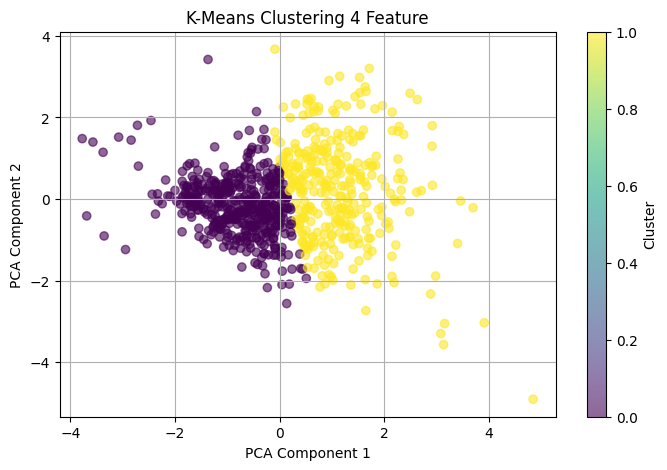

In [139]:
# 2. Hapus kolom BloodPressure dan SkinThickness dari fitur
X = df[["Glucose", "BMI", "DiabetesPedigreeFunction", "Age"]].values
y_true = df['Outcome'].values  # Simpan label asli untuk evaluasi

# 3. Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Clustering KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 5. Evaluasi clustering
ari = adjusted_rand_score(y_true, cluster_labels)
sil_score = silhouette_score(X_scaled, cluster_labels)

print(f"🎯 Adjusted Rand Index (ARI): {ari:.4f}")
print(f"📏 Silhouette Score         : {sil_score:.4f}")

# 6. Visualisasi 2D (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title("K-Means Clustering 4 Feature")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

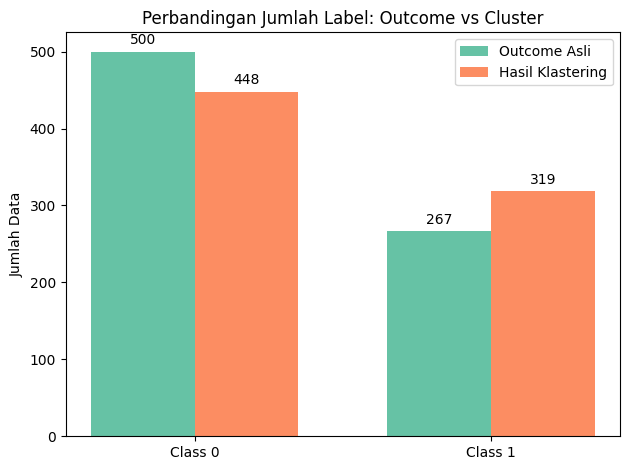

In [153]:
# Buat dataframe gabungan
df_compare3 = pd.DataFrame({
    'Outcome': y_true,
    'Cluster': cluster_labels
})

# Hitung jumlah masing-masing label
outcome_counts = df_compare3['Outcome'].value_counts().sort_index()
cluster_counts = df_compare3['Cluster'].value_counts().sort_index()

# Buat side-by-side bar chart
labels = ['Class 0', 'Class 1']
x = np.arange(len(labels))  # posisi label

width = 0.35  # lebar bar

fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, outcome_counts, width, label='Outcome Asli', color='#66c2a5')
bar2 = ax.bar(x + width/2, cluster_counts, width, label='Hasil Klastering', color='#fc8d62')

# Tambahkan label
ax.set_ylabel('Jumlah Data')
ax.set_title('Perbandingan Jumlah Label: Outcome vs Cluster')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Tampilkan nilai di atas bar
for bar in bar1 + bar2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


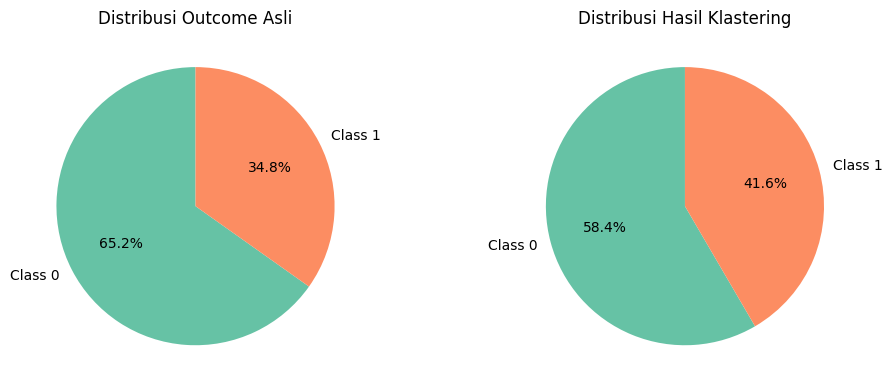

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart untuk Outcome
axes[0].pie(outcome_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[0].set_title('Distribusi Outcome Asli')

# Pie chart untuk Cluster
axes[1].pie(cluster_counts, labels=labels, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Distribusi Hasil Klastering')

plt.tight_layout()
plt.show()

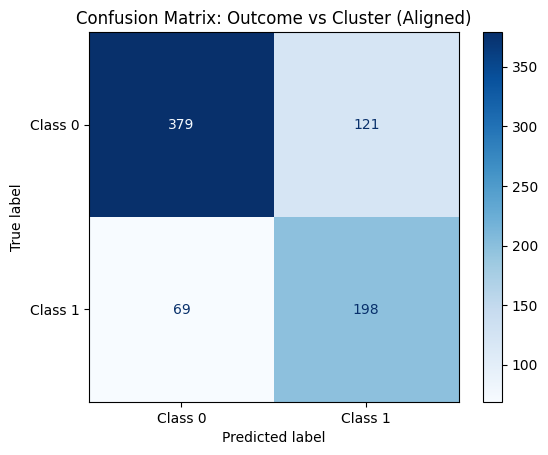

📊 Classification Report (Outcome vs Cluster)
✅ Accuracy : 0.7523
🎯 Precision: 0.6207
📈 Recall   : 0.7416
💡 F1 Score : 0.6758
🔵 ROC AUC  : 0.7498


In [151]:
# Bandingkan dengan label asli
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Align labels (biar 1 = diabetes)
acc_original = accuracy_score(y_true, cluster_labels)
acc_flipped = accuracy_score(y_true, 1 - cluster_labels)

cluster_aligned = 1 - cluster_labels if acc_flipped > acc_original else cluster_labels

# Confusion matrix
cm = confusion_matrix(y_true, cluster_aligned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Outcome vs Cluster (Aligned)")
plt.show()

# Metrics
print("📊 Classification Report (Outcome vs Cluster)")
print(f"✅ Accuracy : {accuracy_score(y_true, cluster_aligned):.4f}")
print(f"🎯 Precision: {precision_score(y_true, cluster_aligned):.4f}")
print(f"📈 Recall   : {recall_score(y_true, cluster_aligned):.4f}")
print(f"💡 F1 Score : {f1_score(y_true, cluster_aligned):.4f}")
print(f"🔵 ROC AUC  : {roc_auc_score(y_true, cluster_aligned):.4f}")


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

labels = np.unique(y_true)

print("🎯 Akurasi Per Kelas:")
for label in labels:
    idx = y_true == label
    acc_label = accuracy_score(cluster_aligned[idx], y_true[idx])
    print(f"🔹 Kelas {label}: Akurasi = {acc_label:.4f}")


🎯 Akurasi Per Kelas:
🔹 Kelas 0: Akurasi = 0.7580
🔹 Kelas 1: Akurasi = 0.7416


In [134]:
# Gabungkan dengan data fitur asli (df awal tanpa Outcome)
df_compare3_full = df.copy()
df_compare3_full['Cluster'] = df_compare3['Cluster']  # atau df_compare3_full = pd.concat([...], axis=1)

# Grouping dan aggregate: mean, min, max
cluster_summary = df_compare3_full.groupby('Cluster').agg(['mean', 'min', 'max']).round(2)

# Transpose agar orientasi lebih mudah dibaca
cluster_summary_transposed = cluster_summary.T

# Tampilkan
print(cluster_summary_transposed)


Cluster                             0       1
Pregnancies              mean    3.00    5.03
                         min     0.00    0.00
                         max    13.00   17.00
Glucose                  mean  103.38  145.40
                         min     0.00   81.00
                         max   175.00  199.00
BloodPressure            mean   65.52   74.13
                         min     0.00    0.00
                         max   122.00  114.00
SkinThickness            mean   19.19   22.39
                         min     0.00    0.00
                         max    52.00   99.00
Insulin                  mean   58.85  109.47
                         min     0.00    0.00
                         max   415.00  846.00
BMI                      mean   29.51   35.47
                         min     0.00    0.00
                         max    55.00   67.10
DiabetesPedigreeFunction mean    0.40    0.57
                         min     0.08    0.09
                         max     1

<Figure size 600x500 with 0 Axes>

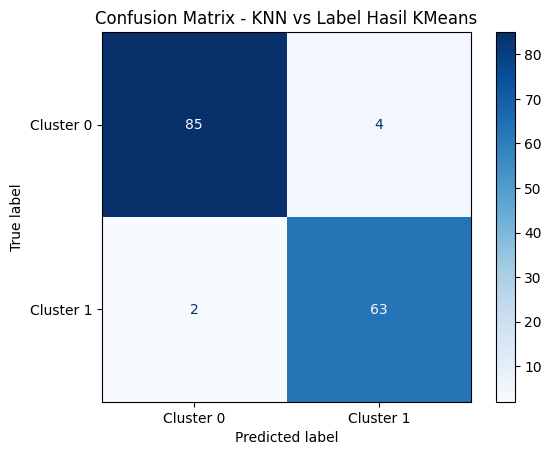

✅ Accuracy: 0.961038961038961

📊 Confusion Matrix:
[[85  4]
 [ 2 63]]

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.94      0.97      0.95        65

    accuracy                           0.96       154
   macro avg       0.96      0.96      0.96       154
weighted avg       0.96      0.96      0.96       154



In [159]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Pilih fitur dan label dari hasil clustering
features = ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df_compare3_full[features].values
y_cluster = df_compare3_full['Cluster'].values  # Label dari hasil KMeans

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cluster, test_size=0.2, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred = knn.predict(X_test)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Buat confusion matrix dan tampilkan
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Cluster {i}" for i in sorted(set(y_cluster))])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - KNN vs Label Hasil KMeans")
plt.grid(False)
plt.show()


print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))


In [160]:
from sklearn.metrics import roc_auc_score

# Dapatkan probabilitas prediksi
y_proba = knn.predict_proba(X_test)

# Jika jumlah kelasnya lebih dari 2, gunakan multiclass ROC AUC
if y_proba.shape[1] > 2:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')  # atau 'ovo'
else:
    auc = roc_auc_score(y_test, y_proba[:, 1])  # untuk binary

print(f"\n🔵 ROC AUC Score: {auc:.4f}")



🔵 ROC AUC Score: 0.9960


<Figure size 600x500 with 0 Axes>

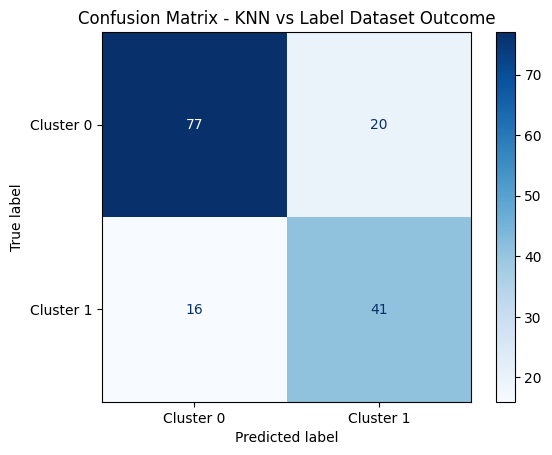

✅ Accuracy: 0.7662337662337663

📊 Confusion Matrix:
[[77 20]
 [16 41]]

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        97
           1       0.67      0.72      0.69        57

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.77      0.77      0.77       154



In [161]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Pilih fitur dan label dari hasil clustering
features = ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df_compare3_full[features].values
y_outcome = df_compare3_full['Outcome'].values  # Label dari hasil KMeans

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_outcome, test_size=0.2, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred = knn.predict(X_test)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Buat confusion matrix dan tampilkan
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Cluster {i}" for i in sorted(set(y_cluster))])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - KNN vs Label Dataset Outcome")
plt.grid(False)
plt.show()


print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

In [163]:
from sklearn.metrics import roc_auc_score

# Dapatkan probabilitas prediksi
y_proba = knn.predict_proba(X_test)

# Jika jumlah kelasnya lebih dari 2, gunakan multiclass ROC AUC
if y_proba.shape[1] > 2:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')  # atau 'ovo'
else:
    auc = roc_auc_score(y_test, y_proba[:, 1])  # untuk binary

print(f"\n🔵 ROC AUC Score: {auc:.4f}")



🔵 ROC AUC Score: 0.8187


### Cluster Selection

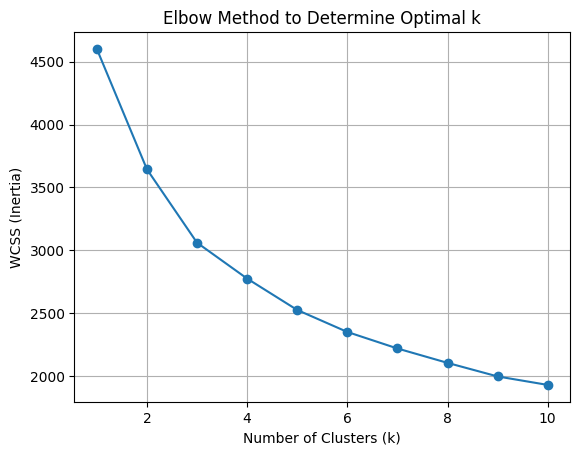

In [78]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS

plt.plot(k_range, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method to Determine Optimal k")
plt.grid(True)
plt.show()

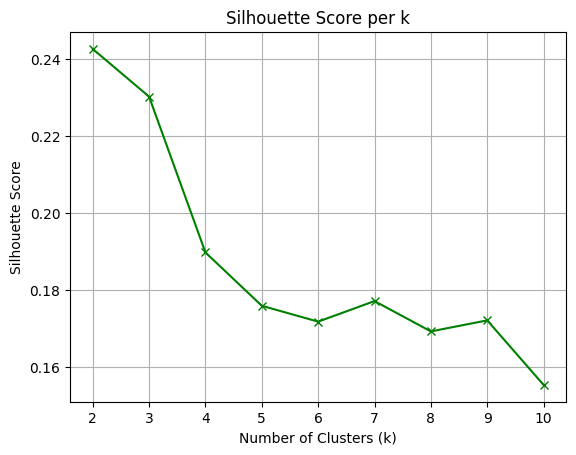

In [79]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.plot(k_range, sil_scores, marker='x', color='green')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per k")
plt.grid(True)
plt.show()


Selain 2 cluster, 3 cluster juga nilai silhoutte cukup baik


🔷 Clustering dengan k = 3
🎯 Adjusted Rand Index (ARI): 0.1810
📏 Silhouette Score         : 0.2551

🔎 Distribusi Outcome vs Cluster:
Cluster 3    0    1    2
Outcome                 
0          322   84   94
1           50  111  106


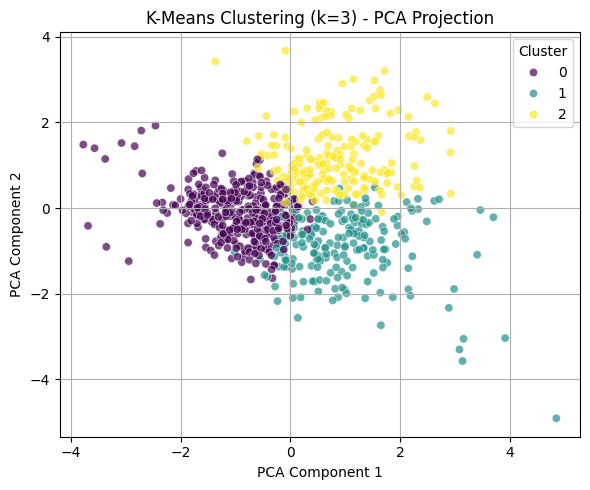

In [11]:
features = ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df[features].values
y_true = df['Outcome'].values

# 2. Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n🔷 Clustering dengan k = 3")
k=3
    # Clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

    # Evaluasi
ari = adjusted_rand_score(y_true, cluster_labels)
sil = silhouette_score(X_scaled, cluster_labels)
print(f"🎯 Adjusted Rand Index (ARI): {ari:.4f}")
print(f"📏 Silhouette Score         : {sil:.4f}")

    # Tabel perbandingan
compare_df = pd.DataFrame({'Outcome': y_true, 'Cluster': cluster_labels})
print("\n🔎 Distribusi Outcome vs Cluster:")
print(pd.crosstab(compare_df['Outcome'], compare_df['Cluster'], rownames=['Outcome'], colnames=[f'Cluster {k}']))

    # Visualisasi PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', alpha=0.7)
plt.title(f"K-Means Clustering (k={k}) - PCA Projection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

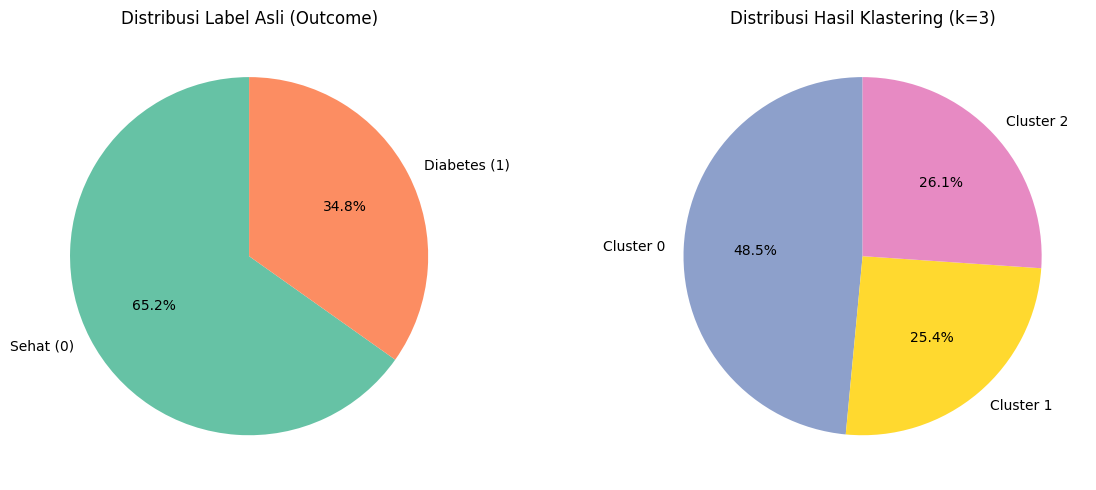

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Hitung distribusi Outcome (label asli)
outcome_counts = pd.Series(y_true).value_counts().sort_index()
outcome_labels = ['Sehat (0)', 'Diabetes (1)']

# Hitung distribusi hasil klastering (k=3)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
cluster_labels_names = [f'Cluster {i}' for i in cluster_counts.index]

# Buat side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart: Outcome asli
axes[0].pie(outcome_counts, labels=outcome_labels, autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[0].set_title('Distribusi Label Asli (Outcome)')

# Pie chart: Cluster hasil KMeans
axes[1].pie(cluster_counts, labels=cluster_labels_names, autopct='%1.1f%%',
            colors=['#8da0cb', '#ffd92f', '#e78ac3'], startangle=90)
axes[1].set_title('Distribusi Hasil Klastering (k=3)')

plt.tight_layout()
plt.show()


In [117]:
# Gabungkan cluster ke dalam dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

# Hitung statistik: mean, min, max
cluster_stats = df_clustered.groupby('Cluster')[features].agg(['mean', 'min', 'max']).round(2)

# Tampilkan
print(cluster_stats)

        Glucose             BMI            DiabetesPedigreeFunction        \
           mean min  max   mean  min   max                     mean   min   
Cluster                                                                     
0        103.03   0  175  29.22  0.0  45.5                     0.34  0.08   
1        136.94  77  199  37.03  0.0  67.1                     0.84  0.20   
2        138.35  57  197  32.23  0.0  48.8                     0.36  0.08   

                 Age          
          max   mean min max  
Cluster                       
0        0.97  26.42  21  47  
1        2.42  30.98  21  58  
2        0.90  48.06  28  81  


#### Membuktikan apakah clustering yang dilakukan valid

✅ Accuracy: 0.9545454545454546
🎯 Precision: 0.9563
📈 Recall   : 0.9459
💡 F1 Score : 0.9507
🔵 ROC AUC  : 0.9950


<Figure size 600x500 with 0 Axes>

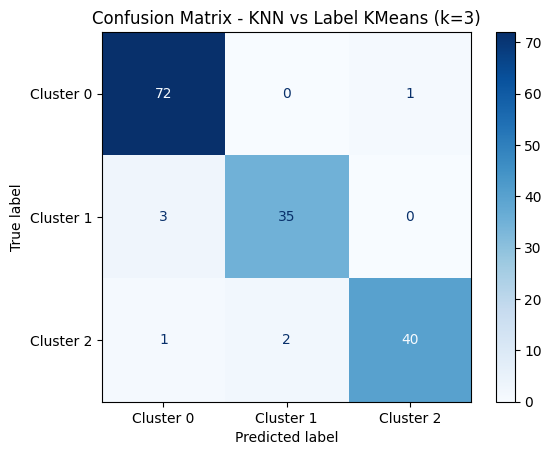


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        73
           1       0.95      0.92      0.93        38
           2       0.98      0.93      0.95        43

    accuracy                           0.95       154
   macro avg       0.96      0.95      0.95       154
weighted avg       0.95      0.95      0.95       154



In [12]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Gunakan X_scaled dari proses sebelumnya (fitur yang sudah dinormalisasi)
# Gunakan cluster_labels sebagai label untuk training
X_train, X_test, y_train, y_test = train_test_split(X_scaled, cluster_labels, test_size=0.2, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)  # untuk ROC AUC

# Evaluasi
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print(f"🎯 Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"📈 Recall   : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"💡 F1 Score : {f1_score(y_test, y_pred, average='macro'):.4f}")

# ROC AUC (macro untuk multiclass)
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovo', average='macro')
print(f"🔵 ROC AUC  : {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Cluster {i}" for i in range(3)])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - KNN vs Label KMeans (k=3)")
plt.grid(False)
plt.show()

# Optional: Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))


#### Akurasi yang diperoleh tinggi yang menandakan bahwa hasil dari clustering valid